# Customer Churn Prediction
### By Dhiraj Dalvi

This notebook contains the complete analysis and machine learning workflow for predicting telecom customer churn.

---

## Table of Contents
1. Import Libraries
2. Load Dataset
3. Data Exploration & Understanding
4. Data Preprocessing
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. Model Training & Evaluation
8. Model Comparison
9. Feature Importance Analysis
10. Save Model & Pipeline
11. New Customer Prediction Demo
12. Conclusion

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)
import joblib
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv('../data/telco_customer_churn_cleaned.csv')
print(f'Dataset Shape: {df.shape}')
print(f'Number of Rows: {df.shape[0]}')
print(f'Number of Columns: {df.shape[1]}')
df.head()

Dataset Shape: (7043, 21)
Number of Rows: 7043
Number of Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Exploration & Understanding

In [3]:
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Missing Values ===')
print(df.isnull().sum())
print(f'\nTotal Missing: {df.isnull().sum().sum()}')

=== Data Types ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pap

In [4]:
print('=== Statistical Summary (Numerical) ===')
df.describe()

=== Statistical Summary (Numerical) ===


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [5]:
print('=== Statistical Summary (Categorical) ===')
df.describe(include='object')

=== Statistical Summary (Categorical) ===


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [6]:
print('=== Unique Values per Column ===')
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')

=== Unique Values per Column ===
customerID: 7043 unique values
gender: 2 unique values
SeniorCitizen: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
tenure: 73 unique values
PhoneService: 2 unique values
MultipleLines: 3 unique values
InternetService: 3 unique values
OnlineSecurity: 3 unique values
OnlineBackup: 3 unique values
DeviceProtection: 3 unique values
TechSupport: 3 unique values
StreamingTV: 3 unique values
StreamingMovies: 3 unique values
Contract: 3 unique values
PaperlessBilling: 2 unique values
PaymentMethod: 4 unique values
MonthlyCharges: 1585 unique values
TotalCharges: 6531 unique values
Churn: 2 unique values


In [7]:
print('=== Target Variable Distribution ===')
print(df['Churn'].value_counts())
print(f'\nChurn Rate: {(df["Churn"] == "Yes").mean() * 100:.2f}%')

=== Target Variable Distribution ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


## 4. Data Preprocessing

In [8]:
df_processed = df.copy()

df_processed['TotalCharges'] = pd.to_numeric(df_processed['TotalCharges'], errors='coerce')
missing_total = df_processed['TotalCharges'].isnull().sum()
print(f'Missing TotalCharges after conversion: {missing_total}')
df_processed['TotalCharges'].fillna(df_processed['TotalCharges'].median(), inplace=True)

df_processed['Churn'] = df_processed['Churn'].map({'Yes': 1, 'No': 0})
print(f'\nChurn encoded: {df_processed["Churn"].value_counts().to_dict()}')

df_processed.drop(columns=['customerID'], inplace=True)
print(f'\nProcessed shape: {df_processed.shape}')
df_processed.head()

Missing TotalCharges after conversion: 0

Churn encoded: {0: 5174, 1: 1869}

Processed shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 5. Exploratory Data Analysis (EDA)

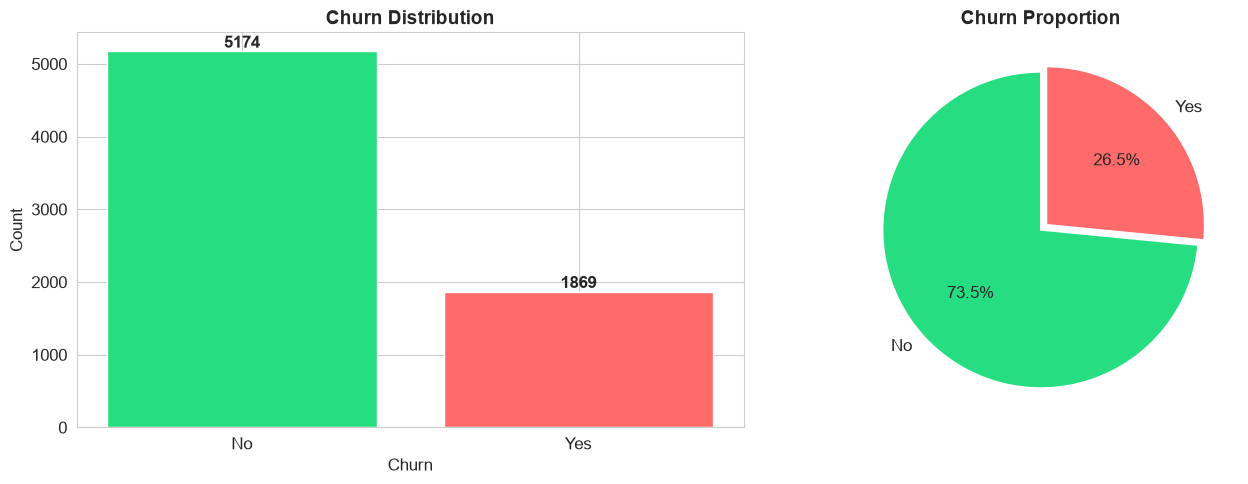

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_counts = df['Churn'].value_counts()
colors = ['#26de81', '#ff6b6b']

axes[0].bar(churn_counts.index, churn_counts.values, color=colors)
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0, 0.05])
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../visualizations/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

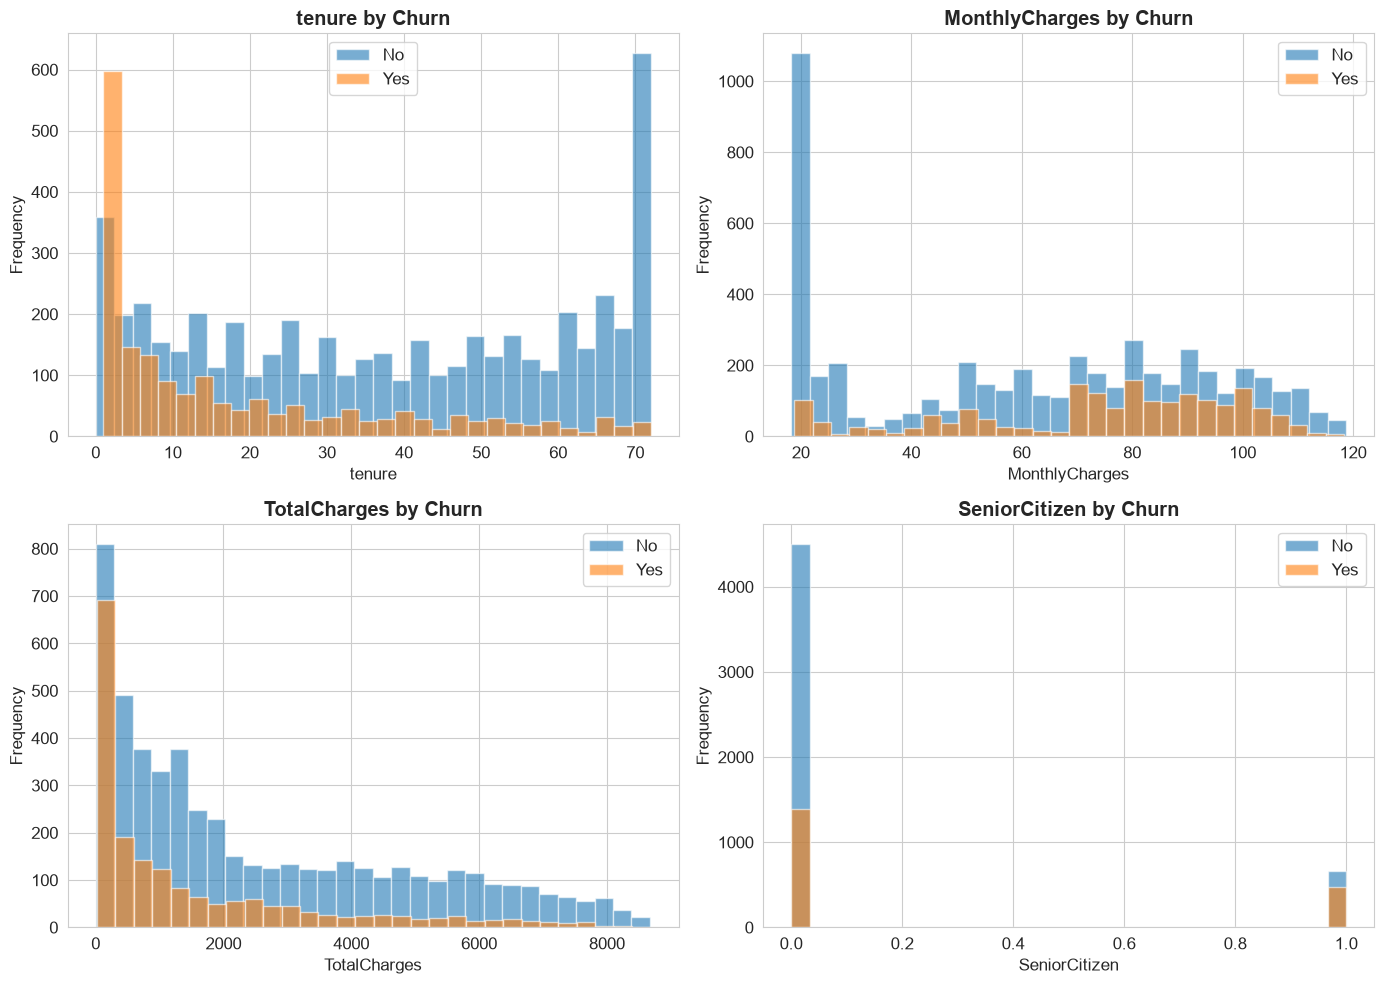

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
for i, col in enumerate(numerical_cols):
    ax = axes[i // 2, i % 2]
    df.groupby('Churn')[col].plot(kind='hist', alpha=0.6, ax=ax, legend=True, bins=30)
    ax.set_title(f'{col} by Churn', fontweight='bold')
    ax.set_xlabel(col)

plt.tight_layout()
plt.savefig('../visualizations/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

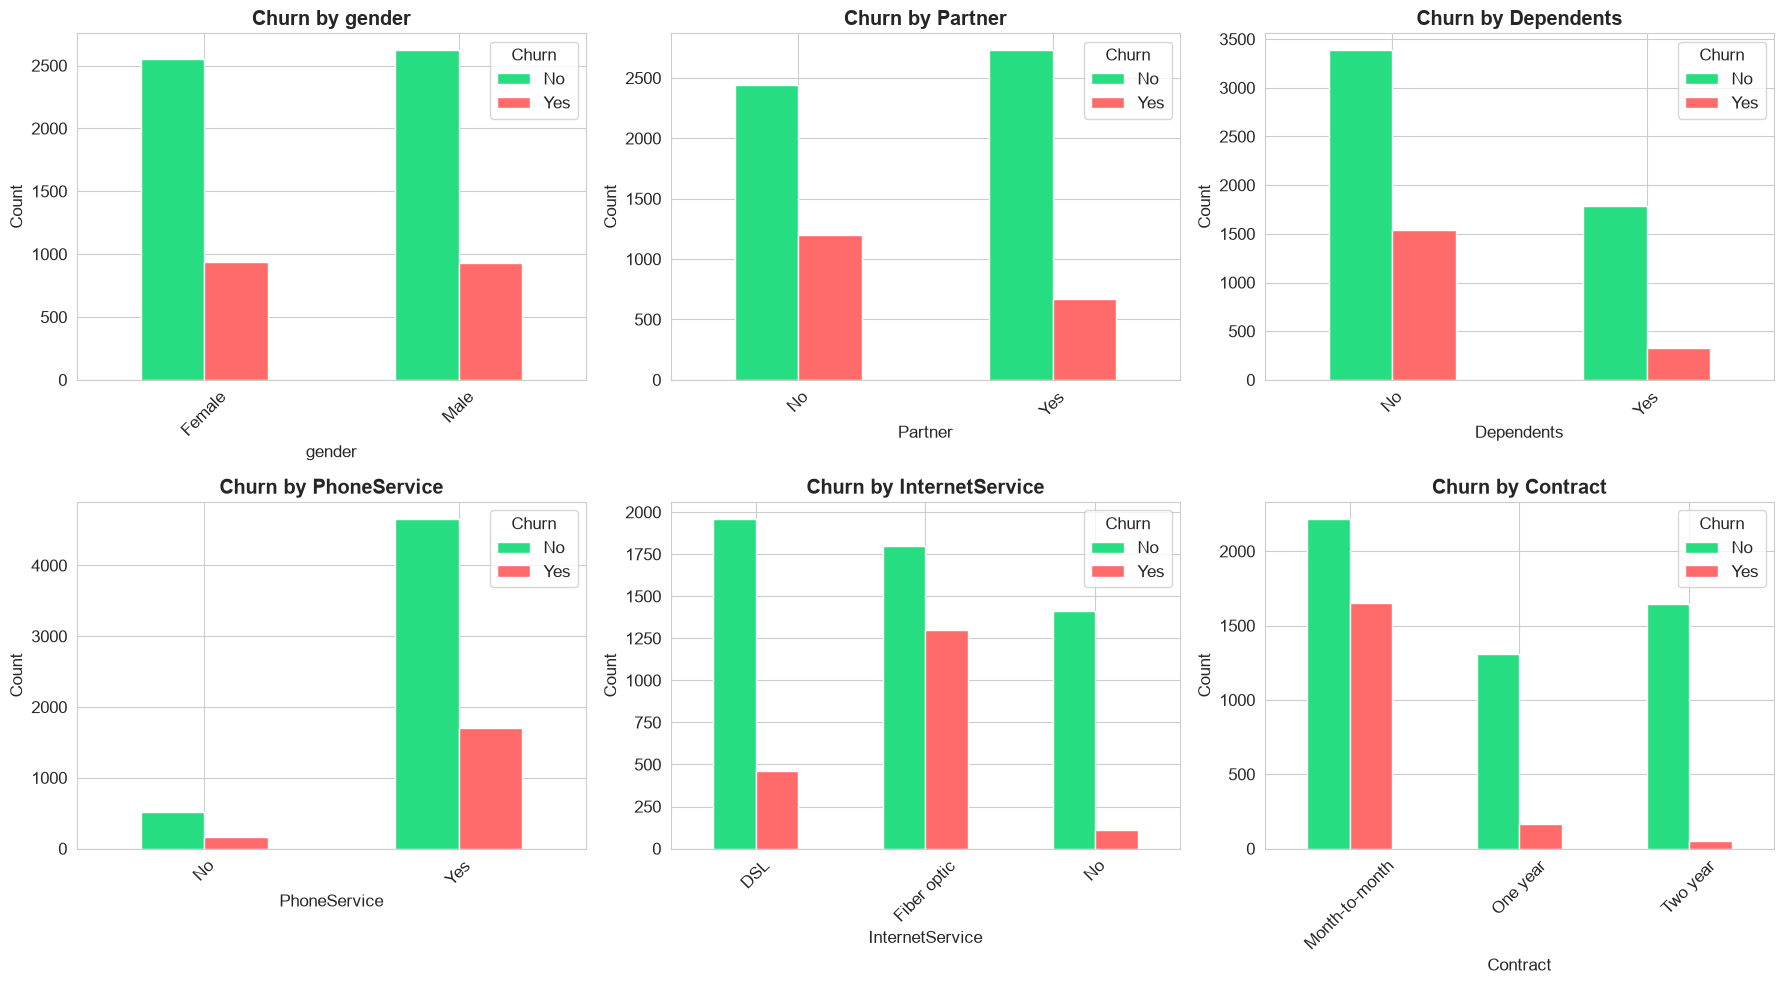

In [11]:
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 'Contract']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(cat_cols):
    ax = axes[i // 3, i % 3]
    ct = pd.crosstab(df[col], df['Churn'])
    ct.plot(kind='bar', ax=ax, color=['#26de81', '#ff6b6b'])
    ax.set_title(f'Churn by {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../visualizations/categorical_churn.png', dpi=150, bbox_inches='tight')
plt.show()

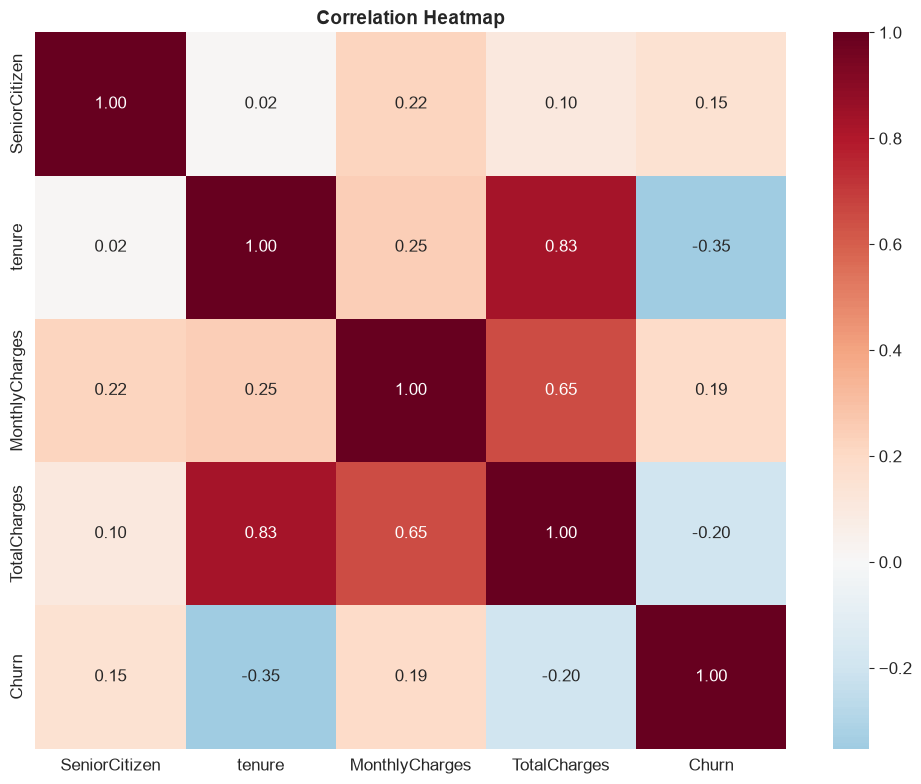

In [12]:
num_df = df_processed[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
plt.figure(figsize=(10, 8))
sns.heatmap(num_df.corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

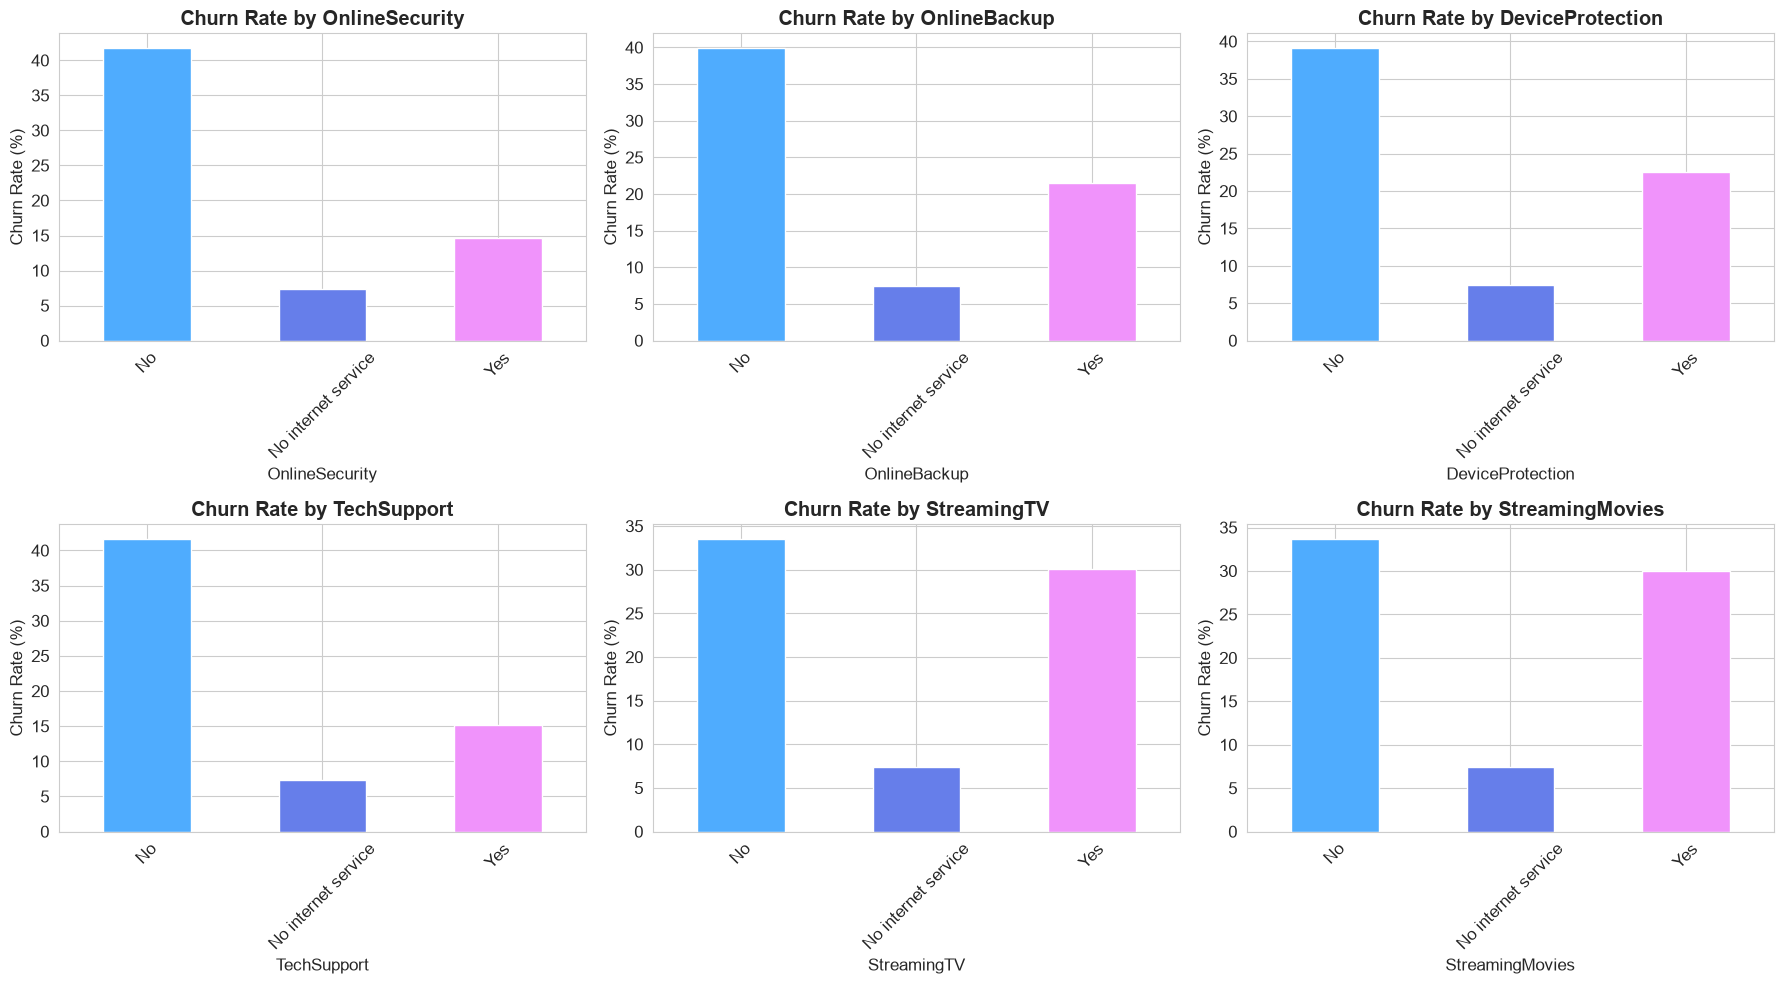

In [13]:
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(services):
    ax = axes[i // 3, i % 3]
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate.plot(kind='bar', ax=ax, color=['#4facfe', '#667eea', '#f093fb'])
    ax.set_title(f'Churn Rate by {col}', fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../visualizations/service_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Engineering

In [14]:
CATEGORICAL_COLS = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

NUMERICAL_COLS = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

X = df_processed.drop(columns=['Churn'])
y = df_processed['Churn']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Features shape: (7043, 19)
Target shape: (7043,)
Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'Train churn rate: {y_train.mean() * 100:.2f}%')
print(f'Test churn rate: {y_test.mean() * 100:.2f}%')

Train set: 5634 samples
Test set: 1409 samples
Train churn rate: 26.54%
Test churn rate: 26.54%


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERICAL_COLS),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), CATEGORICAL_COLS),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
print(f'Processed feature count: {X_train_processed.shape[1]}')
print(f'Feature names (first 10): {list(feature_names[:10])}')

Processed feature count: 30
Feature names (first 10): ['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges', 'num__TotalCharges', 'cat__gender_Male', 'cat__Partner_Yes', 'cat__Dependents_Yes', 'cat__PhoneService_Yes', 'cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes']


## 7. Model Training & Evaluation

In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    print(f'\n{"=" * 60}')
    print(f'Training: {name}')
    print(f'{"=" * 60}')
    
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    
    metrics = {
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
    }
    
    results[name] = {
        'model': model,
        'metrics': metrics,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
    }
    
    print(f'\nMetrics:')
    for metric, value in metrics.items():
        print(f'  {metric}: {value}')
    
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


Training: Logistic Regression

Metrics:
  Accuracy: 0.807
  Precision: 0.6604
  Recall: 0.5615
  F1-Score: 0.6069
  ROC-AUC: 0.8422

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Training: Decision Tree



Metrics:
  Accuracy: 0.7544
  Precision: 0.5389
  Recall: 0.5187
  F1-Score: 0.5286
  ROC-AUC: 0.7465

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.84      0.83      1035
       Churn       0.54      0.52      0.53       374

    accuracy                           0.75      1409
   macro avg       0.68      0.68      0.68      1409
weighted avg       0.75      0.75      0.75      1409


Training: Random Forest



Metrics:
  Accuracy: 0.785
  Precision: 0.6187
  Recall: 0.4947
  F1-Score: 0.5498
  ROC-AUC: 0.8248

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.62      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409


Training: Gradient Boosting



Metrics:
  Accuracy: 0.7977
  Precision: 0.654
  Recall: 0.5053
  F1-Score: 0.5701
  ROC-AUC: 0.8415

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.87      1035
       Churn       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



## 8. Model Comparison

In [18]:
comparison_data = []
for name, res in results.items():
    row = {'Model': name}
    row.update(res['metrics'])
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print('=== Model Comparison ===')
comparison_df

=== Model Comparison ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8070,0.6604,0.5615,0.6069,0.8422
1,Decision Tree,0.7544,0.5389,0.5187,0.5286,0.7465
2,Random Forest,0.7850,0.6187,0.4947,0.5498,0.8248
3,Gradient Boosting,0.7977,0.6540,0.5053,0.5701,0.8415


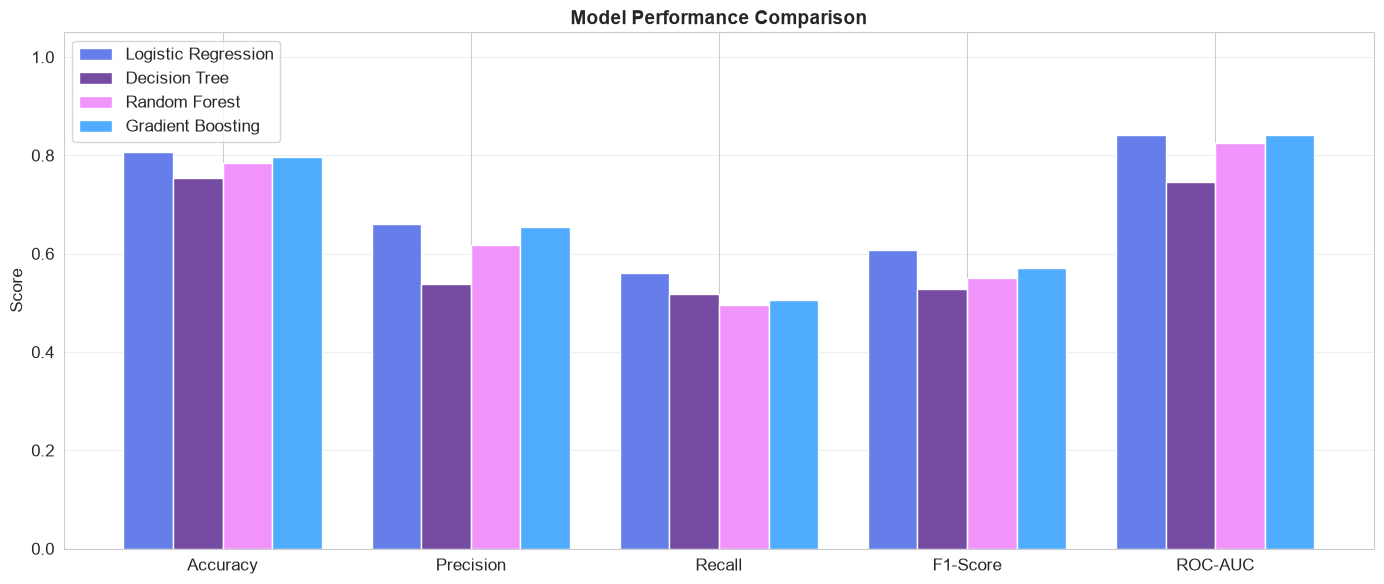

In [19]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(metric_cols))
width = 0.2
colors = ['#667eea', '#764ba2', '#f093fb', '#4facfe']

for i, (_, row) in enumerate(comparison_df.iterrows()):
    values = [row[m] for m in metric_cols]
    ax.bar(x + i * width, values, width, label=row['Model'], color=colors[i])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_cols)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

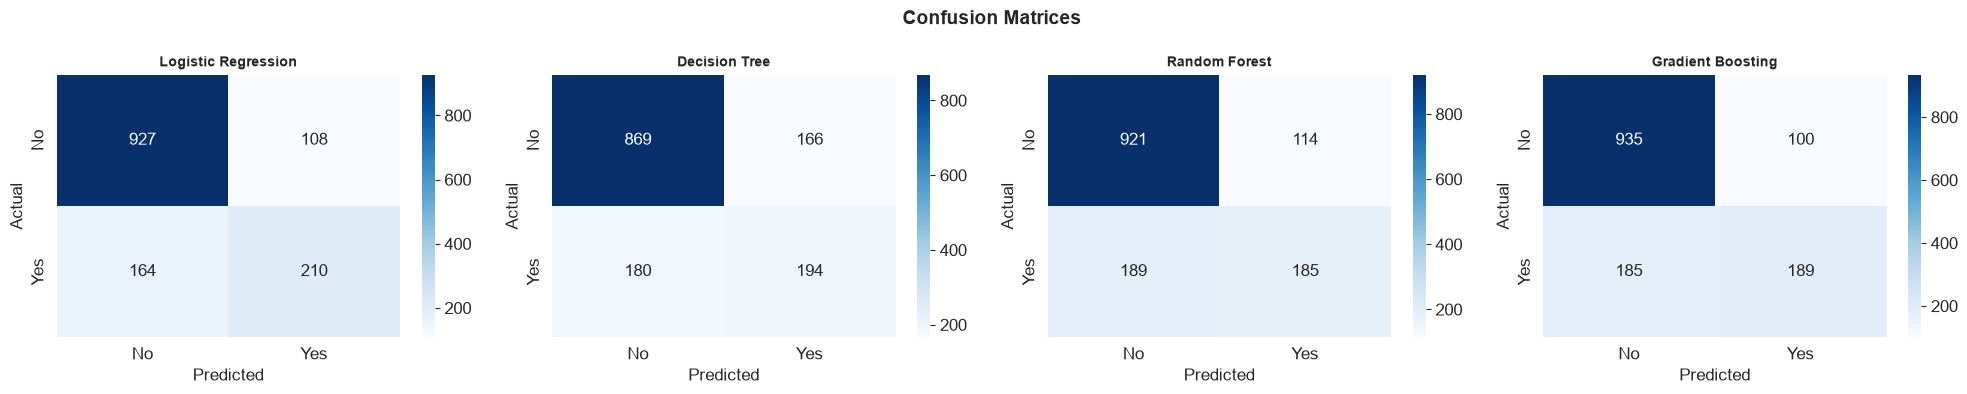

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
model_names = list(results.keys())

for i, name in enumerate(model_names):
    cm = results[name]['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    axes[i].set_title(f'{name}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

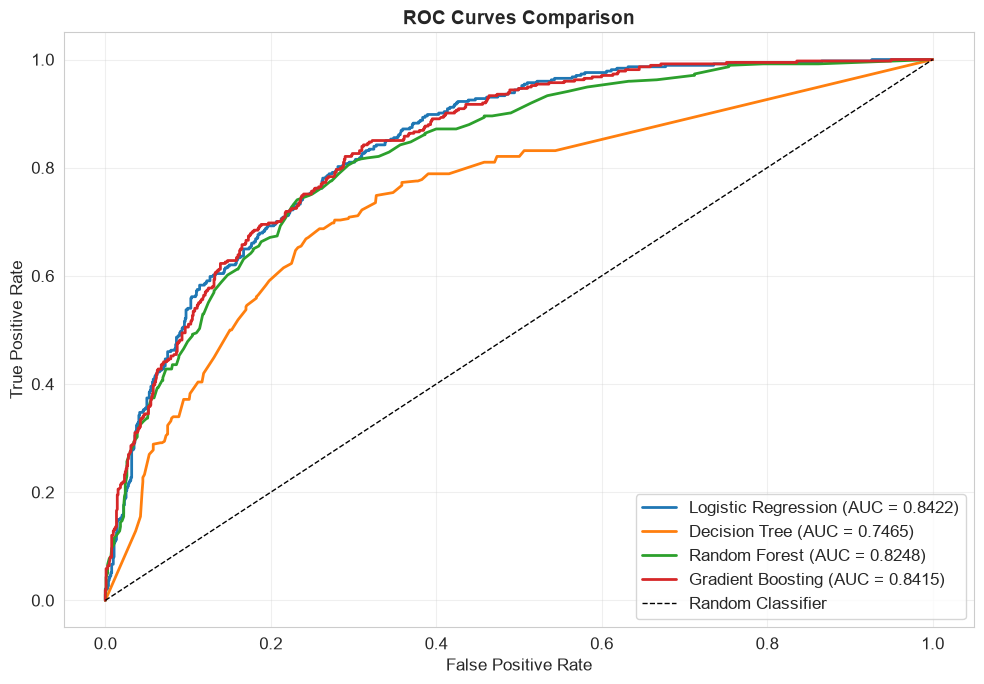

In [21]:
plt.figure(figsize=(10, 7))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = res['metrics']['ROC-AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Importance Analysis

Best Model: Logistic Regression
Best F1-Score: 0.6069


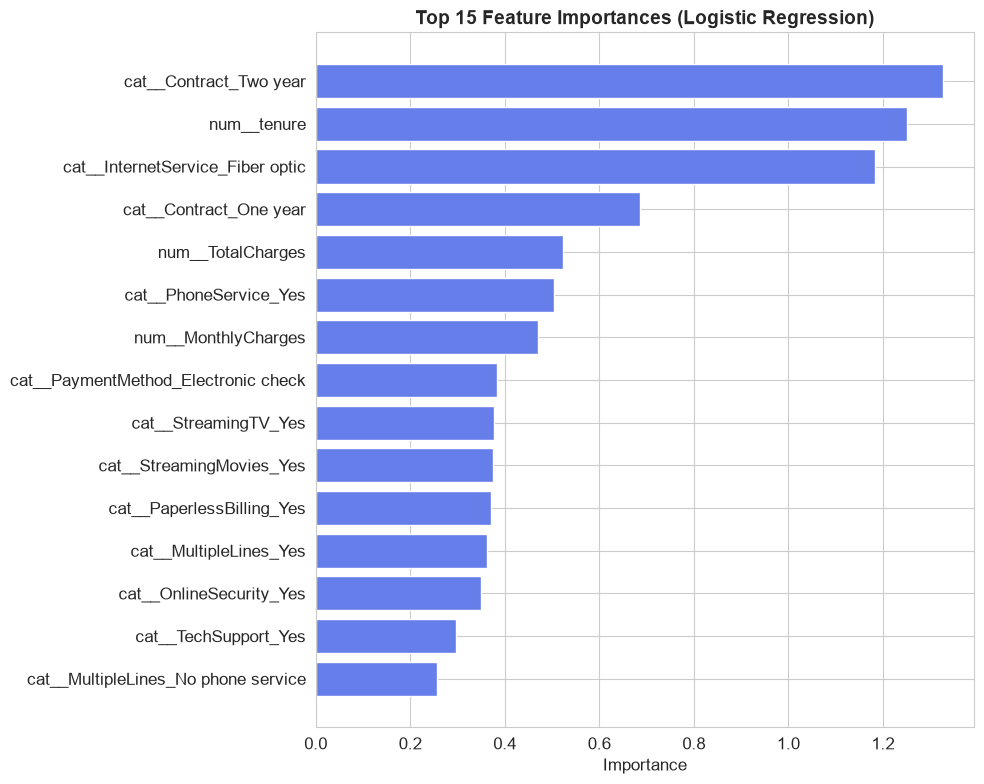

In [22]:
best_model_name = max(results, key=lambda k: results[k]['metrics']['F1-Score'])
best_model = results[best_model_name]['model']
print(f'Best Model: {best_model_name}')
print(f'Best F1-Score: {results[best_model_name]["metrics"]["F1-Score"]}')

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True).tail(15)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#667eea')
plt.xlabel('Importance')
plt.title(f'Top 15 Feature Importances ({best_model_name})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Model & Pipeline

In [23]:
os.makedirs('../models', exist_ok=True)

joblib.dump(preprocessor, '../models/preprocessor.pkl')
joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(best_model_name, '../models/best_model_name.pkl')
joblib.dump(feature_names, '../models/feature_names.pkl')

results_save = {}
for name, res in results.items():
    results_save[name] = {'metrics': res['metrics']}
joblib.dump(results_save, '../models/results.pkl')

print('Model and preprocessor saved successfully!')
print(f'Best model: {best_model_name}')
print(f'Files saved in ../models/')

Model and preprocessor saved successfully!
Best model: Logistic Regression
Files saved in ../models/


## 11. New Customer Prediction Demo

In [24]:
new_customer = {
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 2,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 70.7,
    'TotalCharges': 151.65,
}

new_df = pd.DataFrame([new_customer])
new_processed = preprocessor.transform(new_df)
prediction = best_model.predict(new_processed)[0]
probability = best_model.predict_proba(new_processed)[0]

print('=== New Customer Prediction ===')
print(f'Prediction: {"Churn" if prediction == 1 else "No Churn"}')
print(f'Churn Probability: {probability[1]*100:.2f}%')
print(f'Retention Probability: {probability[0]*100:.2f}%')

=== New Customer Prediction ===
Prediction: Churn
Churn Probability: 69.70%
Retention Probability: 30.30%


## 12. Conclusion

### Key Findings:
1. **Churn Rate**: Approximately 26.5% of customers churned, indicating a significant churn problem.
2. **Key Churn Drivers**: Month-to-month contracts, fiber optic internet without add-on services, electronic check payments, and short tenure are strong predictors of churn.
3. **Protective Factors**: Two-year contracts, tech support, online security, and longer tenure are associated with lower churn rates.
4. **Model Performance**: Multiple models were compared including Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.
5. **Best Model**: The model with the highest F1-Score was selected as the final model for deployment.

### Recommendations:
- Offer incentives for customers to switch from month-to-month to longer-term contracts
- Bundle security and tech support services with internet plans
- Target new customers (low tenure) with retention programs
- Monitor customers using electronic check payments for early churn signals
- Provide additional value to fiber optic customers to justify higher charges